<a href="https://colab.research.google.com/github/yatin299/ML-LAB/blob/Logistical-Regression/Logistical_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  9128  100  9128    0     0  18316      0 --:--:-- --:--:-- --:--:-- 18316
Shapes: (614, 7) (614,) (154, 7) (154,)

Confusion Matrix:
 [[88 12]
 [19 35]]
Accuracy: 0.7987 (79%)


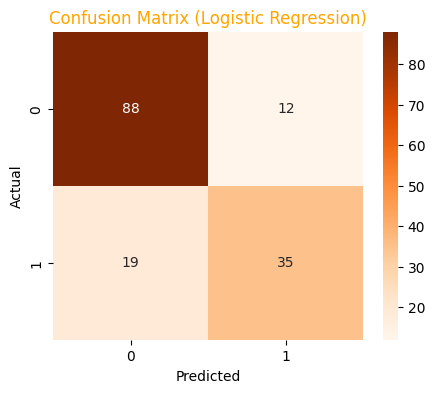

In [1]:
# download & unzip dataset
!curl -L -o /content/diabetes-data-set.zip  https://www.kaggle.com/api/v1/datasets/download/mathchi/diabetes-data-set
!unzip -q /content/diabetes-data-set.zip -d /content/diabetes_data
!rm /content/diabetes-data-set.zip

# imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

# load dataset
column_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'outcome']
df = pd.read_csv('/content/diabetes_data/diabetes.csv', header=None, names=column_names)
df = df.drop(0)  # drop original header row

# convert to numeric
for col in column_names:
    if col != 'outcome':
        df[col] = pd.to_numeric(df[col])

# features & target
feature_columns = ["pregnant", "insulin", "bmi", "age", "glucose", "bp", "pedigree"]
X = df[feature_columns]
y = df.outcome

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)
print("Shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# train logistic regression
model = LogisticRegression(max_iter=1000, solver="lbfgs")
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# metrics
acc = metrics.accuracy_score(y_test, y_pred)
print("\nConfusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred))
print(f"Accuracy: {acc:.4f} ({int(acc*100)}%)")

# heatmap confusion matrix
conf_mat = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
plt.figure(figsize=(5,4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix (Logistic Regression)", color="orange")
plt.show()
